# Assignment 06 — Fine-tuning AlexNet on SimplicityDB
**Name**: Nigus Bezabh Haile       **Matricola**: 947129

**Goal:** fine-tune AlexNet on **SimplicityDB** dataset, compare it with the custom CNN model on the test set, select the best configuration, and analyze its errors.

## 1. Imports

In [ ]:
import os
import zipfile
import copy
import random
import shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("PyTorch version:", torch.__version__)

## 2. Reproducibility and Device Setup

In [ ]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")   # Apple Silicon Mac
else:
    device = torch.device("cpu")

print("Using device:", device)

num_workers = 0
batch_size = 32
epochs = 15
patience = 5

## Dataset Extraction

In [ ]:
zip_path = "./SimplicityDB.zip"
extracted_path = "/media/nigus-haile/Local/EDU/milano_bicocca/2nd_semester/Supervised/2_Ensemble/ES05/SimplicityDB"

if os.path.exists(zip_path) and not os.path.exists(extracted_path):
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(".")
    print(f"Extracted dataset to {extracted_path}")
else:
    print("Dataset already extracted or zip file not found.")

train_path = os.path.join(extracted_path, "train")
test_path  = os.path.join(extracted_path, "test")

assert os.path.exists(train_path), f"Training folder not found: {train_path}"
assert os.path.exists(test_path), f"Test folder not found: {test_path}"

print("Train dataset path:", train_path)
print("Test dataset path:", test_path)

## 4. Transforms

In [ ]:
# AlexNet was originally trained on ImageNet-sized images.
# Therefore, all images are resized to 224x224 and normalized with ImageNet statistics.

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

## Load Dataset and Create Train/Validation/Test Loaders

In [ ]:
train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
validation_dataset = datasets.ImageFolder(train_path, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_path, transform=eval_transform)

class_names = full_train_aug.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))

# 80% train, 20% validation split from the training.
train_len = int(0.8 * len(train_dataset))
val_len = len(train_dataset) - train_len

generator = torch.Generator().manual_seed(SEED)
train_subset_aug, val_subset_aug = random_split(
    train_dataset,
    [train_len, val_len],
    generator=generator
)

train_indices = train_subset_aug.indices
val_indices = val_subset_aug.indices

train_dataset = Subset(full_train_aug, train_indices)
val_dataset = Subset(full_train_eval, val_indices)

trainloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

valloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

testloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print(f"Train size: {len(train_dataset)}")
print(f"Val size:   {len(val_dataset)}")
print(f"Test size:  {len(test_dataset)}")

## Class Distribution

In [ ]:
def get_targets_from_subset(subset):
    return [subset.dataset.samples[i][1] for i in subset.indices]

train_targets = get_targets_from_subset(train_dataset)
val_targets = get_targets_from_subset(val_dataset)
test_targets = [label for _, label in test_dataset.samples]

dist_df = pd.DataFrame({
    "Class": class_names,
    "Train": [Counter(train_targets)[i] for i in range(num_classes)],
    "Validation": [Counter(val_targets)[i] for i in range(num_classes)],
    "Test": [Counter(test_targets)[i] for i in range(num_classes)],
})

dist_df

## 7. Utility Functions

In [ ]:
def denormalize_image(img_tensor):
    """Convert normalized tensor image back to displayable image."""
    mean = torch.tensor(imagenet_mean).view(3, 1, 1)
    std = torch.tensor(imagenet_std).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    img = torch.clamp(img, 0, 1)
    return img.permute(1, 2, 0).numpy()


def build_optimizer(model, optimizer_name, lr, weight_decay):
    trainable_params = [p for p in model.parameters() if p.requires_grad]

    if optimizer_name.lower() == "adam":
        return optim.Adam(trainable_params, lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == "adamw":
        return optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == "sgd":
        return optim.SGD(
            trainable_params,
            lr=lr,
            momentum=0.9,
            weight_decay=weight_decay,
            nesterov=True
        )
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")


@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    y_true = []
    y_pred = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)

    return avg_loss, acc, y_true, y_pred


def train_model(model, trainloader, valloader, config, device):
    criterion = nn.CrossEntropyLoss()

    optimizer = build_optimizer(
        model,
        optimizer_name=config["optimizer"],
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    if config.get("scheduler", "plateau") == "cosine":
        scheduler = CosineAnnealingLR(optimizer, T_max=config["epochs"])
    else:
        scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    best_val_loss = float("inf")
    best_epoch = 0
    patience_counter = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(config["epochs"]):
        model.train()

        running_loss = 0.0
        y_true_train = []
        y_pred_train = []

        for images, labels in trainloader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            y_true_train.extend(labels.cpu().numpy())
            y_pred_train.extend(preds.cpu().numpy())

        train_loss = running_loss / len(trainloader.dataset)
        train_acc = accuracy_score(y_true_train, y_pred_train)

        val_loss, val_acc, _, _ = evaluate_model(model, valloader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if config.get("scheduler", "plateau") == "cosine":
            scheduler.step()
        else:
            scheduler.step(val_loss)

        print(
            f'Epoch {epoch+1:02d}/{config["epochs"]} | '
            f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
            f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}'
        )

        # Select best by validation accuracy; break ties using validation loss.
        improved = (val_acc > best_val_acc) or (
            np.isclose(val_acc, best_val_acc) and val_loss < best_val_loss
        )

        if improved:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= config["patience"]:
            print(f"Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_model_wts)

    return model, history, best_val_loss, best_val_acc, best_epoch

## Previous/Custom CNN Baseline Model

In [ ]:
class CustomCNN(nn.Module):
    """Custom CNN baseline similar to the model developed in the previous lecture."""

    def __init__(self, num_classes, conv_channels=(32, 64, 128, 256), dropout=0.35, fc_units=256):
        super().__init__()

        layers = []
        in_channels = 3

        for out_channels in conv_channels:
            layers.extend([
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2)
            ])
            in_channels = out_channels

        self.features = nn.Sequential(*layers)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(conv_channels[-1], fc_units),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_units, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def build_custom_cnn(config, num_classes):
    return CustomCNN(
        num_classes=num_classes,
        conv_channels=config["conv_channels"],
        dropout=config["dropout"],
        fc_units=config["fc_units"]
    )

## AlexNet

In [ ]:
def build_alexnet(config, num_classes):
    model = load_alexnet_pretrained()

    in_features = model.classifier[6].in_features

    fc_mode = config.get("fc_mode", "default")

    # 🔹 DEFAULT (original AlexNet)
    if fc_mode == "default":
        model.classifier[6] = nn.Linear(in_features, num_classes)

    # 🔹 SMALL CUSTOM HEAD
    elif fc_mode == "small":
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    # 🔹 MEDIUM CUSTOM HEAD
    elif fc_mode == "medium":
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    # 🔹 DEEP HEAD (for A+)
    elif fc_mode == "deep":
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 2048),
            nn.ReLU(),
            nn.BatchNorm1d(2048),

            nn.Dropout(0.5),
            nn.Linear(2048, 1024),
            nn.ReLU(),

            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.ReLU(),

            nn.Linear(512, num_classes)
        )

    else:
        raise ValueError("Unknown fc_mode")

    # 🔹 Fine-tuning modes (same as before)
    fine_tune_mode = config["fine_tune_mode"]

    if fine_tune_mode == "classifier_only":
        for param in model.features.parameters():
            param.requires_grad = False

    elif fine_tune_mode == "last_conv_block":
        for param in model.parameters():
            param.requires_grad = False

        for idx in [8, 10]:
            for param in model.features[idx].parameters():
                param.requires_grad = True

        for param in model.classifier.parameters():
            param.requires_grad = True

    elif fine_tune_mode == "full":
        for param in model.parameters():
            param.requires_grad = True

    return model

## Experiment Configurations

In [51]:
EXPERIMENTS = [
    {
        "name": "Previous_CustomCNN_4_layers_AdamW",
        "builder": "custom_cnn",
        "conv_channels": (32, 64, 128, 256),
        "dropout": 0.35,
        "fc_units": 256,
        "optimizer": "adamw",
        "lr": 7e-4,
        "weight_decay": 5e-4,
        "scheduler": "plateau",
        "epochs": epochs,
        "patience": patience
    },
    {
        "name": "Previous_CustomCNN_5_layers_AdamW",
        "builder": "custom_cnn",
        "conv_channels": (32, 64, 128, 256, 256),
        "dropout": 0.40,
        "fc_units": 256,
        "optimizer": "adamw",
        "lr": 5e-4,
        "weight_decay": 5e-4,
        "scheduler": "plateau",
        "epochs": epochs,
        "patience": patience
    },

    {
        "name": "AlexNet_Full_Default",
        "builder": "alexnet",
        "fine_tune_mode": "full",
        "fc_mode": "default",
        "optimizer": "adamw",
        "lr": 1e-4,
        "weight_decay": 1e-4,
        "epochs": epochs,
        "patience": patience
    },
    {
        "name": "AlexNet_Full_SmallFC",
        "builder": "alexnet",
        "fine_tune_mode": "full",
        "fc_mode": "small",
        "optimizer": "adamw",
        "lr": 1e-4,
        "weight_decay": 1e-4,
        "epochs": epochs,
        "patience": patience
    },
    {
        "name": "AlexNet_Full_MediumFC",
        "builder": "alexnet",
        "fine_tune_mode": "full",
        "fc_mode": "medium",
        "optimizer": "adamw",
        "lr": 1e-4,
        "weight_decay": 1e-4,
        "epochs": epochs,
        "patience": patience
    },
    {
        "name": "AlexNet_Full_DeepFC",
        "builder": "alexnet",
        "fine_tune_mode": "full",
        "fc_mode": "deep",
        "optimizer": "adamw",
        "lr": 8e-5,
        "weight_decay": 1e-4,
        "epochs": epochs,
        "patience": patience
    }
]

## Train All Configurations

In [52]:
outputs_dir = Path("./outputs")
models_dir = outputs_dir / "models"
figures_dir = outputs_dir / "figures"
tables_dir = outputs_dir / "tables"

for d in [outputs_dir, models_dir, figures_dir, tables_dir]:
    d.mkdir(parents=True, exist_ok=True)

all_results = []
histories = {}

for config in EXPERIMENTS:
    print("\n" + "=" * 90)
    print("Training:", config["name"])
    print("=" * 90)

    set_seed(SEED)

    if config["builder"] == "custom_cnn":
        model = build_custom_cnn(config, num_classes)
    elif config["builder"] == "alexnet":
        model = build_alexnet(config, num_classes)
    else:
        raise ValueError("Unknown model builder")

    model = model.to(device)

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    model, history, best_val_loss, best_val_acc, best_epoch = train_model(
        model=model,
        trainloader=trainloader,
        valloader=valloader,
        config=config,
        device=device
    )

    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, _, _ = evaluate_model(model, testloader, criterion, device)

    model_path = models_dir / f'{config["name"]}.pth'
    torch.save(model.state_dict(), model_path)

    histories[config["name"]] = history

    result = {
        "Model": config["name"],
        "Fine-tune Mode": config.get("fine_tune_mode", "not applicable"),
        "Conv Channels": str(config.get("conv_channels", "AlexNet")),
        "Dropout": config.get("dropout", "original"),
        "FC Units": config.get("fc_units", "AlexNet original"),
        "Optimizer": config["optimizer"],
        "Learning Rate": config["lr"],
        "Weight Decay": config["weight_decay"],
        "Trainable Params": trainable_params,
        "Total Params": total_params,
        "Best Epoch": best_epoch,
        "Best Val Loss": best_val_loss,
        "Best Val Accuracy": best_val_acc,
        "Test Loss": test_loss,
        "Test Accuracy": test_acc,
        "Saved Model Path": str(model_path)
    }

    all_results.append(result)

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(by=["Best Val Accuracy", "Test Accuracy"], ascending=False).reset_index(drop=True)
results_df.insert(0, "Rank", range(1, len(results_df) + 1))

results_df.to_csv(tables_dir / "model_configuration_results.csv", index=False)
results_df


Training: Previous_CustomCNN_4_layers_AdamW
Total parameters: 457,738
Trainable parameters: 457,738
Epoch 01/15 | Train Loss: 1.8042 | Train Acc: 0.4321 | Val Loss: 1.6936 | Val Acc: 0.4857
Epoch 02/15 | Train Loss: 1.2342 | Train Acc: 0.6196 | Val Loss: 0.9404 | Val Acc: 0.7143
Epoch 03/15 | Train Loss: 1.0298 | Train Acc: 0.6554 | Val Loss: 0.7704 | Val Acc: 0.7643
Epoch 04/15 | Train Loss: 0.8943 | Train Acc: 0.6714 | Val Loss: 0.7642 | Val Acc: 0.7857
Epoch 05/15 | Train Loss: 0.8296 | Train Acc: 0.7107 | Val Loss: 0.6412 | Val Acc: 0.7714
Epoch 06/15 | Train Loss: 0.7416 | Train Acc: 0.7250 | Val Loss: 0.5681 | Val Acc: 0.8071
Epoch 07/15 | Train Loss: 0.7007 | Train Acc: 0.7500 | Val Loss: 0.8420 | Val Acc: 0.7000
Epoch 08/15 | Train Loss: 0.7409 | Train Acc: 0.7429 | Val Loss: 0.5386 | Val Acc: 0.8071
Epoch 09/15 | Train Loss: 0.6805 | Train Acc: 0.7768 | Val Loss: 0.6595 | Val Acc: 0.7929
Epoch 10/15 | Train Loss: 0.6448 | Train Acc: 0.7875 | Val Loss: 0.5375 | Val Acc: 0.7929

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x9216 and 4096x512)

## Validation Accuracy and Loss Curves

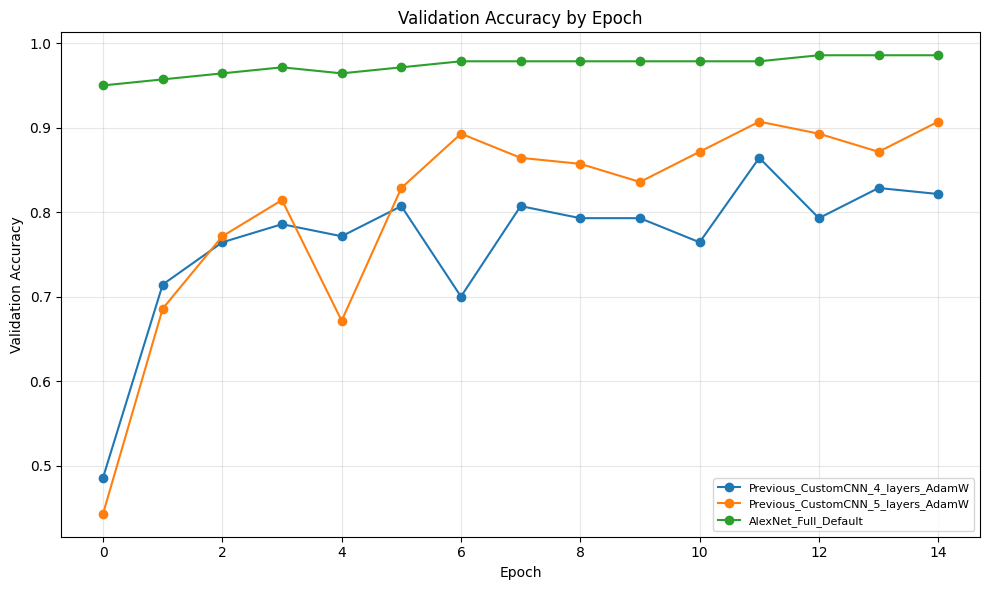

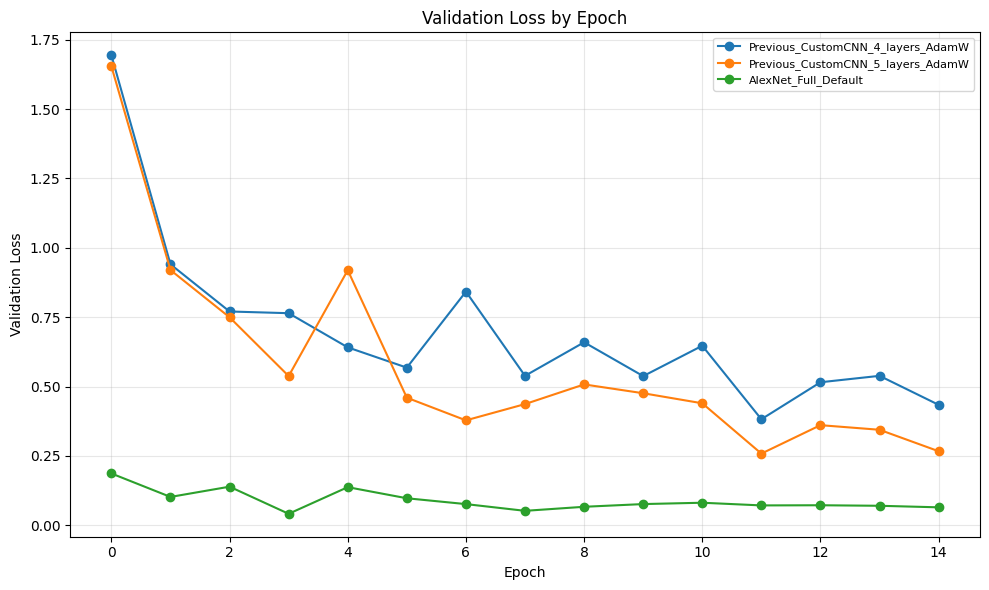

In [53]:
plt.figure(figsize=(10, 6))
for model_name, history in histories.items():
    plt.plot(history["val_acc"], marker="o", label=model_name)

plt.title("Validation Accuracy by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "validation_accuracy_curves.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 6))
for model_name, history in histories.items():
    plt.plot(history["val_loss"], marker="o", label=model_name)

plt.title("Validation Loss by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "validation_loss_curves.png", dpi=200)
plt.show()

## Select Best Model and Evaluate on Test Set

In [54]:
best_row = results_df.iloc[0]
best_model_name = best_row["Model"]
best_model_path = best_row["Saved Model Path"]

print("Best model selected by validation accuracy:")
display(best_row.to_frame().T)

# Rebuild the best model architecture and load saved weights.
best_config = next(cfg for cfg in EXPERIMENTS if cfg["name"] == best_model_name)

if best_config["builder"] == "custom_cnn":
    best_model = build_custom_cnn(best_config, num_classes)
else:
    best_model = build_alexnet(best_config, num_classes)

best_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_model = best_model.to(device)

criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_true, y_pred = evaluate_model(best_model, testloader, criterion, device)

print(f"Best Model: {best_model_name}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Best model selected by validation accuracy:


,Rank,Model,Family,Fine-tune Mode,Conv Channels,Dropout,FC Units,Optimizer,Learning Rate,Weight Decay,Trainable Params,Total Params,Best Epoch,Best Val Loss,Best Val Accuracy,Test Loss,Test Accuracy,Saved Model Path
0,1,AlexNet_FullFineTune_SGD,AlexNet fine-tuning,full,AlexNet,original,AlexNet original,sgd,0.001,0.0001,57044810,57044810,3,0.074475,0.985714,0.193186,0.94,outputs/models/AlexNet_FullFineTune_SGD.pth


StopIteration: 

## Final Comparison Table

In [55]:
comparison_cols = [
    "Model",
    "Family",
    "Fine-tune Mode",
    "Optimizer",
    "Lr",
    "Weight Decay",
    "Val Loss",
    "Val Accuracy",
    "Test Loss",
    "Test Accuracy",
    "Trainable Params"
]

final_comparison_df = results_df[comparison_cols].copy()
final_comparison_df["Best Val Accuracy (%)"] = (final_comparison_df["Best Val Accuracy"] * 100).round(2)
final_comparison_df["Test Accuracy (%)"] = (final_comparison_df["Test Accuracy"] * 100).round(2)

final_comparison_df.to_csv(tables_dir / "final_comparison_table.csv", index=False)
final_comparison_df

KeyError: "['Lr', 'Val Loss', 'Val Accuracy'] not in index"

## Confusion Matrix

<Figure size 800x800 with 0 Axes>

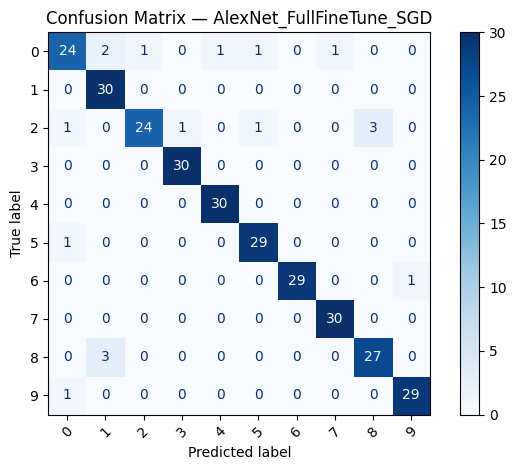

In [56]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45, cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.savefig(figures_dir / "confusion_matrix_best_model.png", dpi=200)
plt.show()

# cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
# cm_df.to_csv(tables_dir / "confusion_matrix.csv")
# cm_df

## Classification Report

In [57]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T
report_df.to_csv(tables_dir / "classification_report.csv")
report_df

,precision,recall,f1-score,support
0,0.888889,0.800000,0.842105,30.00
1,0.857143,1.000000,0.923077,30.00
2,0.960000,0.800000,0.872727,30.00
3,0.967742,1.000000,0.983607,30.00
4,0.967742,1.000000,0.983607,30.00
5,0.935484,0.966667,0.950820,30.00
6,1.000000,0.966667,0.983051,30.00
7,0.967742,1.000000,0.983607,30.00
8,0.900000,0.900000,0.900000,30.00
9,0.966667,0.966667,0.966667,30.00


## Per-Class Accuracy

In [58]:
per_class_rows = []

for i, class_name in enumerate(class_names):
    total = cm[i, :].sum()
    correct = cm[i, i]
    acc = correct / total if total > 0 else 0.0

    per_class_rows.append({
        "Class": class_name,
        "Correct": int(correct),
        "Total": int(total),
        "Per-Class Accuracy": acc,
        "Per-Class Accuracy (%)": round(acc * 100, 2)
    })

per_class_acc_df = pd.DataFrame(per_class_rows).sort_values(
    by="Per-Class Accuracy",
    ascending=True
).reset_index(drop=True)

per_class_acc_df.to_csv(tables_dir / "per_class_accuracy.csv", index=False)
per_class_acc_df

,Class,Correct,Total,Per-Class Accuracy,Per-Class Accuracy (%)
0,0,24,30,0.800000,80.00
1,2,24,30,0.800000,80.00
2,8,27,30,0.900000,90.00
3,6,29,30,0.966667,96.67
4,9,29,30,0.966667,96.67
5,5,29,30,0.966667,96.67
6,3,30,30,1.000000,100.00
7,1,30,30,1.000000,100.00
8,7,30,30,1.000000,100.00
9,4,30,30,1.000000,100.00


## Most Confused Class Pairs

In [59]:
confusion_pairs = []

for true_idx in range(num_classes):
    for pred_idx in range(num_classes):
        if true_idx != pred_idx and cm[true_idx, pred_idx] > 0:
            confusion_pairs.append({
                "True Class": class_names[true_idx],
                "Predicted Class": class_names[pred_idx],
                "Number of Errors": int(cm[true_idx, pred_idx])
            })

confusion_pairs_df = pd.DataFrame(confusion_pairs)

if len(confusion_pairs_df) > 0:
    confusion_pairs_df = confusion_pairs_df.sort_values(
        by="Number of Errors",
        ascending=False
    ).reset_index(drop=True)
else:
    confusion_pairs_df = pd.DataFrame(
        columns=["True Class", "Predicted Class", "Number of Errors"]
    )

confusion_pairs_df.to_csv(tables_dir / "most_confused_pairs.csv", index=False)
confusion_pairs_df.head(20)

,True Class,Predicted Class,Number of Errors
0,2,8,3
1,8,1,3
2,0,1,2
3,0,2,1
4,0,4,1
5,0,7,1
6,0,5,1
7,2,3,1
8,2,0,1
9,2,5,1


## Visualization of Misclassified Images

Displayed misclassified examples: 16




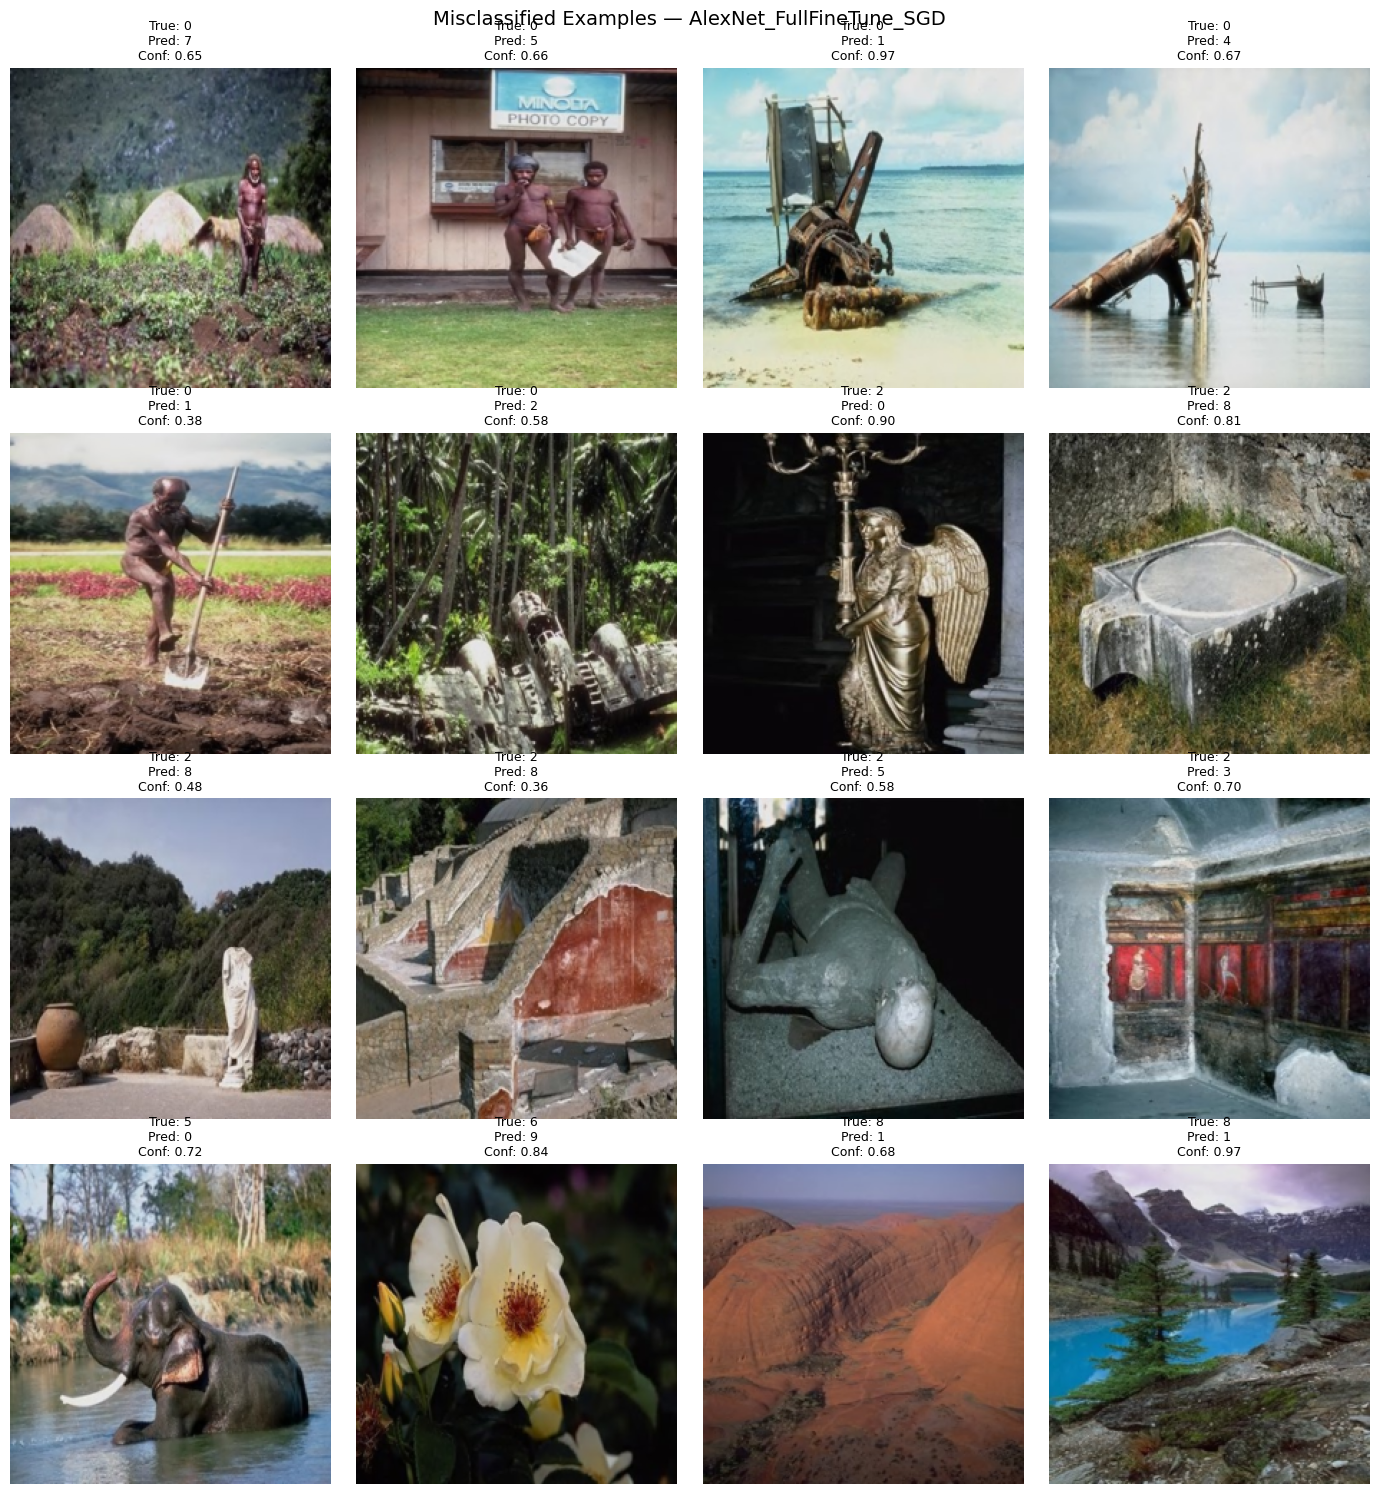

In [60]:
@torch.no_grad()
def collect_misclassified_samples(model, dataset, device, max_samples=16):
    loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)
    mistakes = []

    model.eval()

    for img, label in loader:
        img = img.to(device)
        label = label.to(device)

        output = model(img)
        prob = F.softmax(output, dim=1)
        pred = output.argmax(dim=1)

        if pred.item() != label.item():
            confidence = prob[0, pred.item()].item()
            mistakes.append({
                "image": img.cpu().squeeze(0),
                "true_label": label.item(),
                "pred_label": pred.item(),
                "confidence": confidence
            })

            if len(mistakes) >= max_samples:
                break

    return mistakes


misclassified = collect_misclassified_samples(
    best_model,
    test_dataset,
    device,
    max_samples=16
)

print("Displayed misclassified examples:", len(misclassified))

if len(misclassified) > 0:
    cols = 4
    rows = int(np.ceil(len(misclassified) / cols))

    plt.figure(figsize=(14, 3.8 * rows))

    for i, item in enumerate(misclassified):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(denormalize_image(item["image"]))
        plt.axis("off")

        true_name = class_names[item["true_label"]]
        pred_name = class_names[item["pred_label"]]
        conf = item["confidence"]

        plt.title(
            f"True: {true_name}\nPred: {pred_name}\nConf: {conf:.2f}",
            fontsize=9
        )

    plt.suptitle(f"Misclassified Examples — {best_model_name}", fontsize=14)
    print("\n")
    plt.tight_layout()
    plt.savefig(figures_dir / "misclassified_examples.png", dpi=200)
    plt.show()
else:
    print("No misclassified samples found in the displayed subset.")

## Error Analysis Summary

In [61]:
num_test = len(y_true)
num_errors = int(np.sum(np.array(y_true) != np.array(y_pred)))
error_rate = num_errors / num_test if num_test > 0 else 0.0

worst_classes = per_class_acc_df.head(min(3, len(per_class_acc_df)))
top_confusions = confusion_pairs_df.head(min(5, len(confusion_pairs_df)))

print("Error Analysis Summary")
print("-" * 30)
print(f"Best model: {best_model_name}")
print(f"Test accuracy: {test_acc*100:.2f}%")
print(f"Test error rate: {error_rate*100:.2f}%")
print(f"Number of wrong predictions: {num_errors}/{num_test}")

print("\nWeakest classes:")
display(worst_classes)

print("\nTop confused class pairs:")
display(top_confusions)

Error Analysis Summary
------------------------------
Best model: AlexNet_FullFineTune_SGD
Test accuracy: 93.00%
Test error rate: 6.00%
Number of wrong predictions: 18/300

Weakest classes:


,Class,Correct,Total,Per-Class Accuracy,Per-Class Accuracy (%)
0,0,24,30,0.8,80.0
1,2,24,30,0.8,80.0
2,8,27,30,0.9,90.0



Top confused class pairs:


,True Class,Predicted Class,Number of Errors
0,2,8,3
1,8,1,3
2,0,1,2
3,0,2,1
4,0,4,1
